# Cohort retention analysis

**Question:** of the customers who make their first purchase in a given month, what share come back in each of the following 12 months?

**Method:** group identified customers by the month of their first order (their *cohort*), count how many place an order 0 to 12 months later, and divide by the cohort size. The result feeds the *Cohort and Retention* page of the Power BI report.

In [14]:
# Importing the necessary libraries
import os
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Server and database come from environment variables, so no machine name is hard-coded.
# Set SQL_SERVER (e.g. localhost\SQLEXPRESS) and SQL_DATABASE before running, or keep the defaults.
SQL_SERVER = os.getenv("SQL_SERVER", r"localhost\SQLEXPRESS")
SQL_DATABASE = os.getenv("SQL_DATABASE", "OnlineRetailII")

# Connecting with SQL Server
connection = pyodbc.connect(
    "Driver={ODBC Driver 18 for SQL Server};"
    f"Server={SQL_SERVER};"
    f"Database={SQL_DATABASE};"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

## 1. Build the cohort table in SQL
One row per cohort month, one column per month since first purchase. Month 0 is the acquisition month, so it is always 100%. Cancelled invoices and guest checkouts are excluded.

In [15]:
# Loading the data
query = """with cohort as (
	select 
		format(cus.first_order_date, 'yyyy-MM') [Cohort Month],
		datediff(month, cus.first_order_date, sales.full_date) [Months Since the First Purchase],
		count(distinct sales.customer_id) [Active Customers]
	from rpt.vw_valid_sales sales
	inner join rpt.vw_customer_summary cus
		on sales.customer_id = cus.customer_id
	where cus.customer_key <> -1
	group by format(cus.first_order_date, 'yyyy-MM'), datediff(month, cus.first_order_date, sales.full_date)
)
select 
	[Cohort Month], 
	[0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12]
from cohort
pivot (
	sum([Active Customers])
	for [Months Since the First Purchase] in ([0], [1], [2], [3], [4], [5], [6], [7], [8], [9], [10], [11], [12])
) as piv
order by [Cohort Month];"""

# Load the data and set the index
cohort_df = pd.read_sql(query, connection)
cohort_df = cohort_df.set_index('Cohort Month')

print(cohort_df.head(5))
print(cohort_df.describe())

# Convert counts to retention %
retention = cohort_df.divide(cohort_df['0'], axis=0) * 100

print(retention.head(5))
print(retention.describe())

C:\Users\psoma\AppData\Local\Temp\ipykernel_14004\1854273565.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  cohort_df = pd.read_sql(query, connection)


                0      1      2      3      4      5      6      7      8  \
Cohort Month                                                                
2009-12       951  333.0  317.0  404.0  360.0  342.0  358.0  327.0  321.0   
2010-01       368   79.0  118.0  116.0  100.0  114.0   99.0   86.0  105.0   
2010-02       375   88.0   85.0  110.0   92.0   74.0   72.0  108.0   96.0   
2010-03       441   84.0  102.0  107.0  102.0   90.0  109.0  135.0  122.0   
2010-04       294   56.0   56.0   47.0   54.0   65.0   81.0   78.0   31.0   

                  9     10     11     12  
Cohort Month                              
2009-12       344.0  401.0  472.0  358.0  
2010-01       120.0  114.0   66.0   84.0  
2010-02       104.0   43.0   47.0   57.0  
2010-03        48.0   51.0   64.0   88.0  
2010-04        32.0   22.0   41.0   42.0  
                0           1           2           3           4           5  \
count   25.000000   24.000000   23.000000   22.000000   21.000000   20.000000 

## 2. Heatmap of retention by cohort
Each row is a cohort and each column a month since first purchase. Cells at the bottom right are empty because those months fall after the end of the data (December 2011 is also a partial month), so recent cohorts cannot be compared with old ones at long lags.

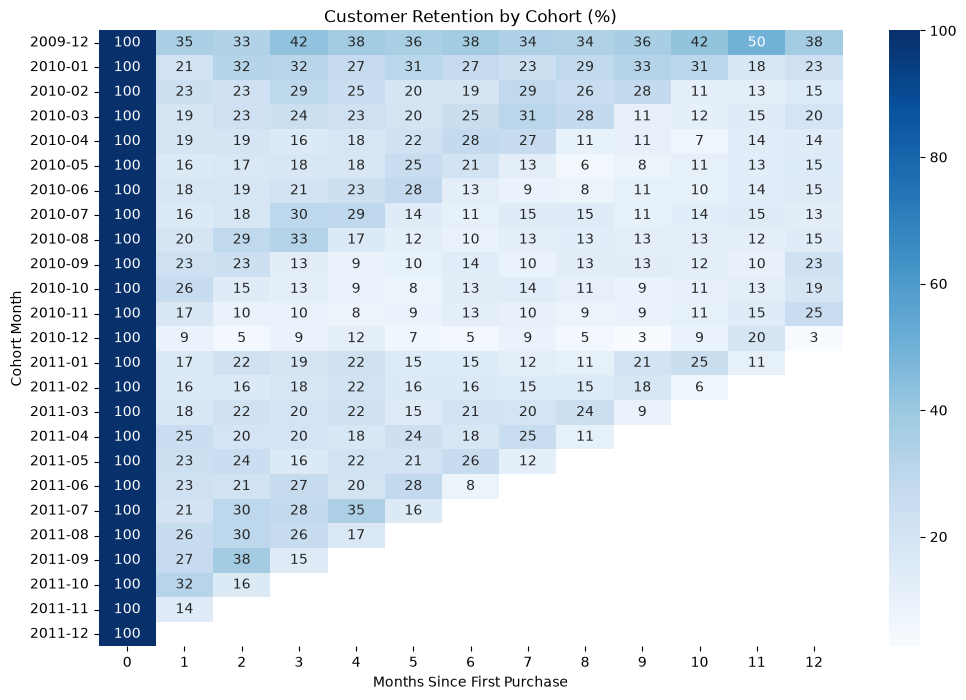

In [16]:
# Creating a heatmap for displaying the customer retention by cohort (%)
plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0f', cmap='Blues')
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.show()

## 3. Check the result
**What the data shows:** across the 25 cohorts, average retention is about 21% in month 1 and 22% in month 2, then slides to about 18% by month 6 and about 15% in months 9 to 10. The December 2009 cohort stands out at 33% to 50% in every month; it is the first cohort in the dataset and likely contains customers who were already active before the data begins, so it should not be read as a typical acquisition cohort. Returns are also higher when the calendar month is October or November (about 24% and 28% of a cohort, against about 13% in January and February), which points to seasonal gift buying.

In [17]:
# Final results
print(cohort_df.columns)
print(retention.head())

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'], dtype='str')
                  0          1          2          3          4          5  \
Cohort Month                                                                 
2009-12       100.0  35.015773  33.333333  42.481598  37.854890  35.962145   
2010-01       100.0  21.467391  32.065217  31.521739  27.173913  30.978261   
2010-02       100.0  23.466667  22.666667  29.333333  24.533333  19.733333   
2010-03       100.0  19.047619  23.129252  24.263039  23.129252  20.408163   
2010-04       100.0  19.047619  19.047619  15.986395  18.367347  22.108844   

                      6          7          8          9         10  \
Cohort Month                                                          
2009-12       37.644585  34.384858  33.753943  36.172450  42.166141   
2010-01       26.902174  23.369565  28.532609  32.608696  30.978261   
2010-02       19.200000  28.800000  25.600000  27.733333  11.466667   
2010-03  

## 4. Reshape to long format
The long format (cohort, month number, retention %) is what Power BI needs to draw the heatmap and line chart.

In [18]:
cohort_long = (
    retention
    .reset_index()
    .melt(
        id_vars=retention.index.name or 'index',
        var_name='month_number',
        value_name='retention_pct'))
cohort_long['month_number'] = cohort_long['month_number'].astype(int)
cohort_long.head(10)

,Cohort Month,month_number,retention_pct
0,2009-12,0,100.0
1,2010-01,0,100.0
2,2010-02,0,100.0
3,2010-03,0,100.0
4,2010-04,0,100.0
5,2010-05,0,100.0
6,2010-06,0,100.0
7,2010-07,0,100.0
8,2010-08,0,100.0
9,2010-09,0,100.0


## 5. Save for Power BI
Writes the long table to `rpt.cohort_retention`.

In [19]:
from sqlalchemy import create_engine

engine = create_engine(
    f"mssql+pyodbc://{SQL_SERVER}/{SQL_DATABASE}"
    "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

cohort_long.to_sql('cohort_retention', engine, schema='rpt', if_exists='replace', index=False)

325